# Experiment 7 — Ablations: Which Mechanism Does the Work?

**Question.** Remove one mechanism at a time; which guarantee or metric degrades, and by how much?

WebAggr is a multi-mechanism system, and multi-mechanism systems invite the suspicion that one
component does all the work. This notebook flips **one switch per arm**, re-measures the **same
34-entity cohort against the same withheld EDGAR answer keys**, and reports one table: mechanism
removed → which metric moved (recall, aggregation error, false-certificate rate, cost) and by how
much. The expected signature (webaggr.pdf §9, item (vi)): each removal degrades exactly the metric
its theorem protects, and nothing else — which is itself evidence the decomposition is right. A
mechanism whose removal changes nothing on real cohorts is honest and useful information too, and
is reported as such.

| arm | mechanism removed | claim isolated (webaggr.pdf) | how it is measured |
|---|---|---|---|
| no ER | entity resolution → group by raw name on the page | C10 — §6, Thm 7 | pool replay |
| majority vote | noisy-OR corroboration → one mention, one vote | C5 — §4.2 | pool replay |
| supersession off | newest-version-wins → versions compete like any value | C5 — §4.3 | pool replay |
| β = 0 | frontier credit stripped from the unseen-mass estimate | C4 — §3.2, §3.4 steps 8–9 | stop replay |
| no checksum engine | aggregate-claim certificates disabled | C8 — §5.2 | stop replay |
| global stopping | one pooled test instead of per-group tests | C3 — §3.3 | imported from Exp 3 |

**Design, pre-registered before any result is looked at.**
The cohort is the 34 **calibration** entities and their frozen A3 reference pools (registry denied).
The validation half stays sealed — a documented deviation from the proposal's "validation cohort"
wording; the quarantine covers all preliminary experiments. Value-side arms re-run the real
resolve → corroborate composition over each frozen pool (the certification harness's own replay
logic: the pool is Π_λ's input), with the fitted gate, the fitted matcher, and **live LLM
adjudication** of ER band pairs — one verdict per pair, cached to disk, so the whole experiment
pays the adjudication bill once. Stopping-side arms replay the stopping decision over each run's
recorded per-step ledger — the Exp-2/Exp-3-sanctioned method; β = 0 is *exact* in replay (both the
estimate and its confidence radius rescale in closed form), while checksum-off changes the stop
rule on a trajectory the engine's gap queries still shaped, so its measured degradation is a
**lower bound** on the true cost of removal. The global-stopping arm is the proposal's own
instruction: "the Cinder failure (Experiment 3's off-arm, reported here as an ablation row)".
Grading uses the pre-registered amount-primary key at the 5% tolerance; the frozen configuration is
the paper-default grid point λ. All arms share every one of these choices — only the one switch
differs.


## 1 · Setup

Load the frozen ingredients — pools, answer keys, fitted gate and matcher — and refuse to run
degraded (a certificate-adjacent number produced through a cold seam certifies nothing).


In [1]:
# --- setup: frozen ingredients, loud preflight, one spend switch --------------
from __future__ import annotations
import contextlib, json, math, os, sys
from pathlib import Path
from collections import defaultdict
from types import SimpleNamespace as NS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":            # run from notebooks/ or the repo root
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
os.chdir(REPO)                          # the package resolves prompts/ and data/ from here

from webagg import config, pipeline, corroboration          # the real pipeline
from webagg.calibration import ConformalGate, load_calibration_set
from webagg.certify import CERT_ATTRS, load_runs_index      # frozen cert conventions
from webagg.entity_resolution import adjudicate_llm         # the real band adjudicator
from webagg.er_pairs import load_fitted_matcher
from webagg.formd import load_truth_cohort
from webagg.frontier import normalize_surface
from webagg.risk_control import fidelity_loss, match_to_truth, usd
from webagg.storage import (get_session, MeasurementRow, MentionRow,
                            SourceRow, FrontierFormulationRow)
from webagg.type_defs import CorroboratedValue

COHORT     = "formd_v2"                       # the frozen A3 cohort
LAM        = dict(config.LTT_GRID[0])         # frozen λ: the paper-default config
AMOUNT_TOL = config.GRADING_AMOUNT_TOL        # pre-registered 5% amount-primary key
EXP_DIR    = config.DATA_DIR / "experiments" / "exp7"
LEDGER     = EXP_DIR / "ledger"               # per-arm, per-entity resumability
FIG_DIR    = REPO / "figures" / "exp7"
for d in (LEDGER, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

RUN_LIVE = False   # <- flip to True on the FIRST pass only: uncached ER band pairs
                   #    escalate to the real LLM adjudicator (webaggr.pdf §6), one
                   #    verdict per pair, written to disk. Every later arm and every
                   #    re-run replays from the cache at zero spend.

# frozen artifacts: answer keys, calibration split, reference-run pools ---------
manifest   = json.loads((config.GROUND_TRUTH_DIR / COHORT / "manifest.json").read_text())
CAL        = list(manifest["split"]["calibration"])   # validation half stays sealed
truths     = load_truth_cohort(config.GROUND_TRUTH_DIR / COHORT)
runs_index = load_runs_index(COHORT)

def db_of(eid: str) -> Path:
    """Pool path; the index stores absolute paths from the machine that ran A3."""
    p = Path(runs_index[eid]["db"])
    return p if p.exists() else config.RUNS_DIR / p.name

# refuse to run degraded (repo rule: loud failure over silent degradation) ------
missing = [e for e in CAL if e not in runs_index or not db_of(e).exists()]
assert not missing, (f"frozen pools missing for {missing[:5]} -- run "
                     "certify_fidelity.py phase 1 (reference runs) first")
missing = [e for e in CAL if e not in truths]
assert not missing, f"answer keys missing for {missing[:5]} (build_truth.py)"
cal_set = load_calibration_set(config.CALIBRATION_SET)
assert cal_set, "conformal gate has no calibration set (seam A1 must be closed)"
GATE = ConformalGate(delta_E=LAM["delta_E"]).fit(cal_set)
MATCHER = load_fitted_matcher(tau_minus=LAM["tau_minus"], tau_plus=LAM["tau_plus"])
assert MATCHER.alpha is not None, "ER matcher is cold (seam A2 must be closed)"
assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY missing from .env"

print(f"cohort        : {len(CAL)} calibration entities (validation sealed)")
print(f"frozen lambda : {LAM}")
print(f"grading       : amount-primary, tol {AMOUNT_TOL} (pre-registered)")


[er] matcher fitted on 460 labeled pairs (148 same / 312 different); alpha=0.3739
cohort        : 34 calibration entities (validation sealed)
frozen lambda : {'tau_plus': 0.85, 'tau_minus': 0.15, 'delta_E': 0.05, 'qbar': 0.3}
grading       : amount-primary, tol 0.05 (pre-registered)


## 2 · Value-side arms: what the pipeline *asserts* with a mechanism removed

Each frozen pool holds every page and every extracted mention one entity's live discovery run
gathered. The pipeline's job downstream of fetching is to turn that pile into records: **entity
resolution** decides which mentions talk about the same funding round (webaggr.pdf §6), and
**corroboration** decides which competing dollar value to believe (§4). Four arms re-run exactly
that composition over every pool, changing one thing at a time:

- **full** — the real system: fitted matcher, live LLM adjudication of borderline pairs, noisy-OR
  belief over independent origins, newest version wins.
- **no ER** — mentions are grouped by the literal (normalized) company name on the page. Different
  spellings of one company fragment into phantom copies of its funding history; the one-to-one
  grading then prices every duplicate as spurious — the failure Thm 7's false-split channel prices.
- **majority vote** — one mention, one vote, no provenance. A value echoed by many copies of one
  press release outvotes the primary document (§4.2's echo trap).
- **supersession off** — a corrected figure no longer kills its stale predecessor; old and new
  versions compete on raw support (§4.3's stale-value adoption).

Each arm is graded per entity against the frozen EDGAR key with the pre-registered amount-primary
rule: **fidelity loss** L (how wrong the asserted records are, in dollars, relative to the entity's
true total), **recall** (how many true rounds were matched), **aggregation error** (how far the
summed answer lands from the true total), and **cost** (LLM adjudication calls — the price of the
mechanism itself). The seven starved entities that asserted nothing in A3 stay in the cohort under
the certification convention (loss 0, recall 0); they offset every arm equally and cancel in the
deltas.


In [2]:
# --- the four value-side arms: one switch each, everything else identical -----

# One verdict per unordered mention pair, cached to DISK: a pair's same/different
# status is a fact about the pair (webaggr.pdf §6), not about the arm asking, so
# every arm and every re-run reuses it. First pass ~= the A3 replay bill (~5.9k
# pairs); afterwards $0.
ADJ_PATH  = EXP_DIR / "adjudications.json"
adj_cache = json.loads(ADJ_PATH.read_text()) if ADJ_PATH.exists() else {}
adj_stats = {"asked": 0, "cached": 0}

def adjudicator(m_a, m_b, lookup):
    key = "|".join(sorted((m_a.mention_id, m_b.mention_id)))
    if key not in adj_cache:
        if not RUN_LIVE:
            raise RuntimeError(
                f"uncached band pair {key} but RUN_LIVE=False -- flip the switch "
                "in the setup cell for the one-time live adjudication pass")
        adj_cache[key] = float(adjudicate_llm(m_a, m_b, lookup))  # the real LLM
        adj_stats["asked"] += 1
        if adj_stats["asked"] % 200 == 0:          # crash-safe: flush periodically
            ADJ_PATH.write_text(json.dumps(adj_cache))
    else:
        adj_stats["cached"] += 1
    return adj_cache[key]

def surface_cluster(mentions, lookup):
    """The no-ER join key: trust the raw name on the page. This is exactly the
    missing-key problem webaggr.pdf §6 exists to solve, left unsolved."""
    return {m.mention_id: normalize_surface(m.entity_surface) for m in mentions}

def majority_corroborate(mentions_by_value, lookup, qtable=None):
    """One mention, one vote: no provenance graph, no independent-origin count,
    no supersession -- the baseline webaggr.pdf §4.2 replaces. Deterministic
    tie-break (most votes, then lexicographic) so replays are reproducible."""
    counts = {v: len(ms) for v, ms in mentions_by_value.items()}
    v, n = min(counts.items(), key=lambda kv: (-kv[1], kv[0]))
    tot = sum(counts.values())
    return CorroboratedValue(
        value=v, belief=n / tot, nu=n, component_sizes=[n],
        competing={u: c / tot for u, c in counts.items() if u != v},
        supporting_mention_ids=[m.mention_id for m in mentions_by_value[v]])

@contextlib.contextmanager
def patched(obj, name, repl):
    """Swap one module-level function for the duration of one replay."""
    orig = getattr(obj, name); setattr(obj, name, repl)
    try:
        yield
    finally:
        setattr(obj, name, orig)

ARMS_VALUE = ["full", "majority_vote", "supersession_off", "no_er"]  # cache-warm order

def replay_arm(eid: str, arm: str) -> dict:
    """Pi_lambda over one frozen pool with one mechanism removed. Same replay
    contract as the certification harness: re-gate, re-resolve, re-corroborate;
    state=None (checksum revalidation and report regimes do not change the
    assembled VALUES, and this experiment grades values)."""
    session = get_session(str(db_of(eid)))
    try:
        kw = dict(run_id=f"exp7_{arm}_{eid}", query_attributes=set(CERT_ATTRS),
                  aggregate_attr="amount", gate=GATE, qbar=LAM["qbar"], state=None)
        if arm == "no_er":                       # C10: replace ER with surface grouping
            return pipeline.resolve_and_aggregate(session, cluster_fn=surface_cluster, **kw)
        if arm == "majority_vote":               # C5: replace noisy-OR with vote counting
            with patched(pipeline, "corroborate", majority_corroborate):
                return pipeline.resolve_and_aggregate(
                    session, matcher=MATCHER, adjudicator=adjudicator, **kw)
        if arm == "supersession_off":            # C5: no version ever supersedes another
            with patched(corroboration, "supersession_edges", lambda sources: []):
                return pipeline.resolve_and_aggregate(
                    session, matcher=MATCHER, adjudicator=adjudicator, **kw)
        return pipeline.resolve_and_aggregate(   # the full system (baseline)
            session, matcher=MATCHER, adjudicator=adjudicator, **kw)
    finally:
        engine = session.get_bind(); session.close(); engine.dispose()

def cv_plain(cv):
    """CorroboratedValue -> the plain dict grading (and diagnostics) read."""
    if cv is None:
        return None
    return {"value": getattr(cv, "value", None),
            "value_num": getattr(cv, "value_num", None),
            "belief": getattr(cv, "belief", None),
            "nu": getattr(cv, "nu", None),
            "n_dead_excluded": getattr(cv, "n_dead_excluded", 0)}

def reshape(plain: list) -> list:
    """Ledger dicts -> the record shape risk_control's graders accept."""
    out = []
    for r in plain:
        attrs = {a: (NS(**cv) if cv else None) for a, cv in r["attributes"].items()}
        out.append({"entity_id": r["entity_id"], "record_kind": r["record_kind"],
                    "attributes": attrs,
                    "contributing_mentions": r["contributing_mentions"]})
    return out

def grade(records: list, truth) -> dict:
    """The four numbers per (arm, entity), all against the frozen EDGAR key."""
    aligned  = match_to_truth(records, truth, amount_tol=AMOUNT_TOL, amount_primary=True)
    matched  = [(r, t) for r, t in aligned if t is not None]
    spurious = sum(usd(r["attributes"].get("amount")) for r, t in aligned if t is None)
    total    = sum(usd(r["attributes"].get("amount")) for r in records)  # f_Q = SUM (§2.2)
    return dict(
        recall=len(matched) / max(truth.true_count, 1),
        loss=fidelity_loss(records, truth, amount_tol=AMOUNT_TOL, amount_primary=True),
        agg_err=abs(total - truth.true_sum) / max(truth.true_sum, 1e-9),
        spurious_share=spurious / max(truth.true_sum, 1e-9),
        n_records=len(records))


In [3]:
# --- run all four arms over all 34 pools (ledger-resumable, skip = loud) ------
rows = []
for arm in ARMS_VALUE:
    for eid in CAL:
        path = LEDGER / f"records_{arm}_{eid}.json"
        if path.exists():
            saved = json.loads(path.read_text())
        else:
            before = adj_stats["asked"] + adj_stats["cached"]
            result = replay_arm(eid, arm)
            plain  = [{"entity_id": r["entity_id"], "record_kind": r["record_kind"],
                       "attributes": {a: cv_plain(cv) for a, cv in r["attributes"].items()},
                       "contributing_mentions": r["contributing_mentions"]}
                      for r in result["records"]]
            saved = {"records": plain,
                     "adj_calls": adj_stats["asked"] + adj_stats["cached"] - before}
            path.write_text(json.dumps(saved))
            ADJ_PATH.write_text(json.dumps(adj_cache))     # verdicts are money: flush
            print(f"[exp7] {arm:>16} {eid}: {len(plain):>3} records, "
                  f"{saved['adj_calls']:>5} adjudications")
        records = reshape(saved["records"])
        g = grade(records, truths[eid])
        g.update(arm=arm, eid=eid, name=runs_index[eid]["entity_name"],
                 adj_calls=saved.get("adj_calls", 0),
                 dead_excluded=sum((cv["n_dead_excluded"] or 0)
                                   for r in saved["records"]
                                   for cv in r["attributes"].values() if cv))
        rows.append(g)

df_value = pd.DataFrame(rows)
value_summary = (df_value.groupby("arm")
                 .agg(loss=("loss", "mean"), recall=("recall", "mean"),
                      agg_err=("agg_err", "mean"),
                      spurious_share=("spurious_share", "mean"),
                      adj_calls=("adj_calls", "sum"),
                      dead_excluded=("dead_excluded", "sum"))
                 .reindex(ARMS_VALUE))
print(f"adjudicator: {adj_stats['asked']} live calls this session, "
      f"{adj_stats['cached']} cache hits, {len(adj_cache)} verdicts on disk")
print("supersession activity meter (stale echoes excluded, full arm):",
      int(value_summary.loc['full', 'dead_excluded']))
value_summary.round(3)


adjudicator: 0 live calls this session, 0 cache hits, 5946 verdicts on disk
supersession activity meter (stale echoes excluded, full arm): 0


,loss,recall,agg_err,spurious_share,adj_calls,dead_excluded
arm,,,,,,
full,0.501,0.299,0.992,1.072,5946,0
majority_vote,0.487,0.290,1.008,1.063,5946,0
supersession_off,0.501,0.299,0.992,1.072,5946,0
no_er,0.501,0.299,1.042,1.122,0,0


## 3 · Stopping-side arms: when the *searcher* stops with a mechanism removed

Discovery is a loop: issue a search, count what came back, and stop a group once its estimated
unseen mass is provably below ε (webaggr.pdf §3.3's two-conjunct rule). Two mechanisms feed that
decision, and both can be removed **in replay** — the loop logged its full per-step state (the
estimate, its confidence radius ψ, the frontier's heat, every checksum certificate, the running
spend), so we re-run the stop decision over the recorded trajectory and ask *when this run would
have ended*:

- **β = 0** — the unseen-mass estimate keeps its Good–Turing term but drops the **frontier credit**:
  planned-but-unissued searches no longer count as evidence that more records may exist (§3.2,
  §3.4 steps 8–9). Exact in replay: the credit-free estimate is `f₁/N` from the same ledger, and
  the radius ψ scales by exactly ½ because every per-occasion increment is proportional to (1+β).
- **no checksum engine** — strata that closed *by constraint* ("we found $X of a corroborated $X
  total", §5.2) lose that exemption and must instead pass the statistical test, and the claim-based
  cardinality brake disappears with the engine.

Grading: every resolved record in the full-system replay is stamped with the ledger step its first
supporting page arrived (mention → page → search → step), so for any stop step we can read off the
recall at that moment, the true records the recorded future still had in store (**lost records**),
and whether a "certified" stop was premature — a **false certificate**. A self-test runs first:
the *unablated* replay must land on every run's actual stop, step and reason, or nothing else here
counts.


In [4]:
# --- load each run's flight recorder; self-test: replay must reproduce reality
def load_ledger(eid: str):
    """Per-step, per-stratum rows of the stop statistic (webaggr.pdf §3.3):
    the estimate U, its radius psi, frontier heat, checksum certificates,
    the claim brake, and the running spend -- plus the run's actual stop."""
    run_id  = runs_index[eid]["run_id"]
    session = get_session(str(db_of(eid)))
    try:
        rows = (session.query(MeasurementRow)
                .filter(MeasurementRow.run_id == run_id,
                        MeasurementRow.metric == "U_hat")
                .order_by(MeasurementRow.step).all())
        per = [dict(step=r.step, stratum=r.stratum, U=r.value,
                    **{k: (r.extra or {}).get(k)
                       for k in ("psi", "N", "f1", "hot", "certified",
                                 "spent", "claimed_count", "formulation_id")})
               for r in rows]
        stop_row = (session.query(MeasurementRow)
                    .filter(MeasurementRow.run_id == run_id,
                            MeasurementRow.metric == "stop")
                    .order_by(MeasurementRow.step.desc()).first())
        stop = ((int(stop_row.step), (stop_row.extra or {}).get("reason"))
                if stop_row else (None, None))
    finally:
        engine = session.get_bind(); session.close(); engine.dispose()
    df = pd.DataFrame(per)
    if len(df):
        # the Exp-3 lesson, one step further: pandas coerces None -> NaN (and
        # NaN is truthy) even on ASSIGNMENT into an object column. Normalize to
        # types pandas cannot mangle: "" for no certificate, plain bools for hot.
        df["certified"] = df["certified"].apply(
            lambda c: c if isinstance(c, str) else "")
        df["hot"] = df["hot"].apply(lambda h: bool(h) if h is not None else False)
    return df, stop

ledgers, actual_stops = {}, {}
for eid in CAL:
    ledgers[eid], actual_stops[eid] = load_ledger(eid)

# preflight: which pools carry a usable per-stratum ledger? --------------------
# A pool with ZERO U_hat rows never formed a stratum -- the starved entities:
# with no per-group stop statistic there is nothing to ablate, so they sit out
# the stopping-side arms (excluded LOUDLY here, mirroring Exp 3's
# pre-registered starved-entity exclusion; value-side arms keep all 34).
# A pool with rows but missing fields predates the Exp-2 instrumentation
# patch and is a hard error, not a silent skip.
needed = ("psi", "spent", "f1", "N")
CAL_STOP, empty, degraded = [], [], []
for eid in CAL:
    d = ledgers[eid]
    if not len(d):
        empty.append(eid)
    elif not all(k in d and d[k].notna().all() for k in needed):
        degraded.append(eid)
    else:
        CAL_STOP.append(eid)
assert not degraded, (
    f"pools with U_hat rows but missing extras {needed}: {degraded} -- these "
    "DBs predate the Exp-2 ledger patch and cannot be replayed "
    "(value-side arms are unaffected)")
if empty:
    print(f"stopping-side cohort: {len(CAL_STOP)} of {len(CAL)} entities; "
          f"{len(empty)} excluded (run never formed a stratum -> no per-group "
          "statistic exists to ablate):")
    for e in empty:
        print(f"    {e} ({runs_index[e]['entity_name']}) -- "
              f"actual stop {actual_stops[e]}")
assert len(CAL_STOP) >= len(CAL) // 2, (
    f"only {len(CAL_STOP)} instrumented pools -- too few to ablate stopping on; "
    "something beyond the starved entities is wrong with the ledgers")

def replay_stop(df, eps, budget, terminal, *, beta0=False, no_checksum=False):
    """First step the per-group rule (§3.3: budget guard, then the two
    conjuncts per stratum) fires on the RECORDED trajectory, with at most one
    mechanism removed. Returns (step, reason); terminal if it never fires."""
    if not len(df):                     # no strata ever formed: nothing to test
        return terminal
    for step, grp in df.groupby("step", sort=True):
        if float(grp["spent"].max()) >= budget:          # budget checked first,
            return int(step), "budget"                   # as in the live loop
        ok = True
        for row in grp.itertuples():
            if row.certified and not no_checksum:
                continue                    # closed by checksum: exempt (§5.2)
            if (not no_checksum and pd.notna(row.claimed_count)
                    and row.N < row.claimed_count):
                ok = False; break           # claim-based cardinality brake
            U   = row.f1 / max(row.N, 1) if beta0 else row.U   # §3.2: drop the credit
            psi = row.psi / 2.0 if beta0 else row.psi          # psi ∝ (1+β): exact
            if not (U + psi < eps):
                ok = False; break           # conjunct (i): unseen mass below eps
            if row.hot:
                ok = False; break           # conjunct (ii): frontier still hot
        if ok and len(grp) > 0:             # cold-start guard, as in the loop
            return int(step), "certified"
    return terminal

# SELF-TEST: the unablated replay IS the live rule -- it must land on every
# instrumented run's own stop, step and reason, or nothing downstream counts.
for eid in CAL_STOP:
    got = replay_stop(ledgers[eid], runs_index[eid]["eps"],
                      config.BUDGET_USD, actual_stops[eid])
    assert got == actual_stops[eid], (
        f"replay diverges from reality for {eid}: replay={got}, "
        f"actual={actual_stops[eid]} -- instrumentation or replay logic wrong")
print(f"self-test: replay reproduces the actual stop on all "
      f"{len(CAL_STOP)} instrumented runs")


stopping-side cohort: 27 of 34 entities; 7 excluded (run never formed a stratum -> no per-group statistic exists to ablate):
    cik0001712223 (Prenda) -- actual stop (6, 'frontier_exhausted')
    cik0001783848 (Omsom) -- actual stop (6, 'frontier_exhausted')
    cik0001783955 (System Initiative) -- actual stop (5, 'economic')
    cik0001799591 (Equip Health) -- actual stop (6, 'frontier_exhausted')
    cik0001832759 (Settle) -- actual stop (6, 'frontier_exhausted')
    cik0001959571 (Magic AI) -- actual stop (6, 'frontier_exhausted')
    cik0001982311 (Unstructured) -- actual stop (6, 'frontier_exhausted')
self-test: replay reproduces the actual stop on all 27 instrumented runs


In [5]:
# --- the two ablated stop replays, graded against each pool's own future ------
def first_steps(eid: str, df) -> dict:
    """mention_id -> ledger step its page arrived (mention -> page -> search ->
    earliest step that search appears in the ledger; proposal-step fallback)."""
    fid_step = df.groupby("formulation_id")["step"].min().to_dict() \
        if "formulation_id" in df else {}
    run_id  = runs_index[eid]["run_id"]
    session = get_session(str(db_of(eid)))
    try:
        prop = {f.formulation_id: f.step for f in
                session.query(FrontierFormulationRow).filter_by(run_id=run_id)}
        src_fid = {s.source_id: s.formulation_id for s in session.query(SourceRow)}
        pairs = [(m.mention_id, m.source_id) for m in session.query(MentionRow)]
    finally:
        engine = session.get_bind(); session.close(); engine.dispose()
    out = {}
    for mid, sid in pairs:
        fid = src_fid.get(sid)
        v = fid_step.get(fid)
        if v is None:
            v = prop.get(fid, 1)          # proposal step: errs early, counted
        out[mid] = max(int(v or 1), 1)
    return out

def truth_record_steps(eid: str) -> list:
    """For each truth record the FULL system matched: the step it was first
    reachable. This is the yardstick every stop is graded against."""
    saved   = json.loads((LEDGER / f"records_full_{eid}.json").read_text())
    records = reshape(saved["records"])
    aligned = match_to_truth(records, truths[eid],
                             amount_tol=AMOUNT_TOL, amount_primary=True)
    steps   = first_steps(eid, ledgers[eid])
    return [min((steps.get(mid, 1) for mid in r["contributing_mentions"]),
                default=1)
            for r, t in aligned if t is not None]

def hopeless_strata(df, eps) -> int:
    """Checksum-off diagnostic: strata that DID close by checksum but whose
    statistical test never passes anywhere in the recorded horizon -- the
    'burn budget on hopeless statistical certificates' prediction."""
    n = 0
    for g, sub in df.groupby("stratum"):
        if (sub["certified"] != "").any():
            if not ((sub["U"] + sub["psi"]) < eps).any():
                n += 1
    return n

stop_rows = []
for eid in CAL_STOP:
    df, term = ledgers[eid], actual_stops[eid]
    eps      = runs_index[eid]["eps"]
    tsteps   = truth_record_steps(eid)                 # the pool's own future
    n_truth  = max(truths[eid].true_count, 1)
    spend_at = df.groupby("step")["spent"].max()
    for arm, kw in [("full", {}), ("beta0", {"beta0": True}),
                    ("checksum_off", {"no_checksum": True})]:
        s, why = (term if arm == "full"
                  else replay_stop(df, eps, config.BUDGET_USD, term, **kw))
        found  = sum(1 for t in tsteps if t <= s)
        lost   = len(tsteps) - found                   # truth records forfeited
        stop_rows.append(dict(
            arm=arm, eid=eid, name=runs_index[eid]["entity_name"],
            stop_step=s, reason=why,
            spent=float(spend_at.get(s, spend_at.max() if len(spend_at) else 0.0)),
            recall_at_stop=found / n_truth, lost_records=lost,
            false_cert=bool(why == "certified" and lost > 0),
            hopeless_strata=hopeless_strata(df, eps) if arm == "checksum_off" else 0))

df_stop = pd.DataFrame(stop_rows)
stop_summary = (df_stop.groupby("arm")
                .agg(stop_step=("stop_step", "mean"), spent=("spent", "mean"),
                     recall_at_stop=("recall_at_stop", "mean"),
                     lost_records=("lost_records", "sum"),
                     false_cert_rate=("false_cert", "mean"),
                     n_certified=("reason", lambda r: int((r == "certified").sum())),
                     hopeless_strata=("hopeless_strata", "sum"))
                .reindex(["full", "beta0", "checksum_off"]))
stop_summary.round(3)


,stop_step,spent,recall_at_stop,lost_records,false_cert_rate,n_certified,hopeless_strata
arm,,,,,,,
full,22.481,0.433,0.377,0,0.0,5,0
beta0,22.481,0.433,0.377,0,0.0,5,0
checksum_off,22.481,0.433,0.377,0,0.0,5,6


## 4 · The global-stopping row, imported from Experiment 3

The proposal assigns this arm to Experiment 3's off-arm ("reported here as an ablation row"):
replacing the per-group tests with one pooled test is only distinguishable on *portfolios* of
groups, which Exp 3 built by construction (one small "Cinder" company hidden among three large
ones). This cell imports Exp 3's saved stop table and summary and condenses the stratified-vs-global
contrast into one row of the ablation table.


In [6]:
# --- import Experiment 3's off-arm (the proposal's designated source) ---------
EXP3 = config.DATA_DIR / "experiments" / "exp3"
exp3_summary, exp3_stops = None, None
if (EXP3 / "exp3_summary.csv").exists():
    exp3_summary = pd.read_csv(EXP3 / "exp3_summary.csv")
    exp3_stops   = pd.read_csv(EXP3 / "exp3_stop_table.csv")
    full = exp3_summary[exp3_summary["variant"] == "full"].set_index("arm")
    # the contrast C3 protects: the WORST group's recall at stop, and how often
    # a certificate fired while a member was silently missing
    global_row = dict(
        worst_recall_strat=float(full.loc["stratified", "mean_worst_recall"]),
        worst_recall_glob=float(full.loc["global", "mean_worst_recall"]),
        silent_fail_strat=float(full.loc["stratified", "silent_failure_rate"]),
        silent_fail_glob=float(full.loc["global", "silent_failure_rate"]),
        spend_strat=float(full.loc["stratified", "mean_spend_usd"]),
        spend_glob=float(full.loc["global", "mean_spend_usd"]),
        step_strat=float(full.loc["stratified", "mean_stop_step"]),
        step_glob=float(full.loc["global", "mean_stop_step"]),
        n=int(full.loc["global", "n_portfolios"]))
    print(f"Exp 3 imported: {global_row['n']} portfolios | mean stop step "
          f"stratified {global_row['step_strat']:.1f} vs global "
          f"{global_row['step_glob']:.1f} | mean worst-group recall "
          f"{global_row['worst_recall_strat']:.2f} vs "
          f"{global_row['worst_recall_glob']:.2f}")
else:
    global_row = None
    print(f"Exp 3 artifacts not found under {EXP3} -- the global-stopping row "
          "will read 'pending' (run exp3_stratified_vs_global.ipynb first)")


Exp 3 artifacts not found under D:\Projects\webagg\data\experiments\exp3 -- the global-stopping row will read 'pending' (run exp3_stratified_vs_global.ipynb first)


## 5 · The ablation table

One row per removed mechanism. A cell is filled only where the arm's measurement path actually
touches that metric — a stop-rule replay cannot re-price asserted dollar values, and a pool replay
never re-decides when to stop searching; the blank cells are the design, not missing data (each arm
isolates one claim, and the untouched metrics have their own dedicated experiments).


In [7]:
# --- the ablation table: mechanism removed -> which metric moved, by how much -
def vrow(arm):   return value_summary.loc[arm]
def srow(arm):   return stop_summary.loc[arm]
base_v, base_s = vrow("full"), srow("full")

def rel(x, b):
    """Delta vs the full system, signed (positive = metric got worse/bigger)."""
    return float(x - b)

table = []
for arm, label, claim in [("no_er", "no entity resolution", "C10 (§6, Thm 7)"),
                          ("majority_vote", "majority vote", "C5 (§4.2)"),
                          ("supersession_off", "supersession off", "C5 (§4.3)")]:
    v = vrow(arm)
    table.append(dict(
        mechanism_removed=label, claim=claim,
        cohort=f"{len(CAL)} entities (pool replay)",
        recall=v["recall"], d_recall=rel(v["recall"], base_v["recall"]),
        fidelity_loss=v["loss"], d_loss=rel(v["loss"], base_v["loss"]),
        agg_error=v["agg_err"], d_agg=rel(v["agg_err"], base_v["agg_err"]),
        false_cert_rate=np.nan, d_false_cert=np.nan,
        cost=v["adj_calls"], d_cost=rel(v["adj_calls"], base_v["adj_calls"]),
        cost_unit="LLM adjudications"))
for arm, label, claim in [("beta0", "no frontier credit (β=0)", "C4 (§3.2, §3.4)"),
                          ("checksum_off", "no checksum engine", "C8 (§5.2)")]:
    s = srow(arm)
    table.append(dict(
        mechanism_removed=label, claim=claim,
        cohort=f"{len(CAL_STOP)} entities (stop replay)",
        recall=s["recall_at_stop"],
        d_recall=rel(s["recall_at_stop"], base_s["recall_at_stop"]),
        fidelity_loss=np.nan, d_loss=np.nan, agg_error=np.nan, d_agg=np.nan,
        false_cert_rate=s["false_cert_rate"],
        d_false_cert=rel(s["false_cert_rate"], base_s["false_cert_rate"]),
        cost=s["spent"], d_cost=rel(s["spent"], base_s["spent"]),
        cost_unit="search $ at stop"))
if global_row:
    table.append(dict(
        mechanism_removed="global stopping", claim="C3 (§3.3)",
        cohort=f"{global_row['n']} Exp-3 portfolios",
        recall=global_row["worst_recall_glob"],
        d_recall=global_row["worst_recall_glob"] - global_row["worst_recall_strat"],
        fidelity_loss=np.nan, d_loss=np.nan, agg_error=np.nan, d_agg=np.nan,
        false_cert_rate=global_row["silent_fail_glob"],
        d_false_cert=global_row["silent_fail_glob"] - global_row["silent_fail_strat"],
        cost=global_row["spend_glob"],
        d_cost=global_row["spend_glob"] - global_row["spend_strat"],
        cost_unit="search $ at stop"))
else:
    table.append(dict(mechanism_removed="global stopping", claim="C3 (§3.3)",
                      cohort="pending (run Exp 3)", cost_unit=""))

# baseline row on top, for reference
table.insert(0, dict(
    mechanism_removed="— none (full system)", claim="—",
    cohort=f"{len(CAL)} entities",
    recall=base_v["recall"], d_recall=0.0,
    fidelity_loss=base_v["loss"], d_loss=0.0,
    agg_error=base_v["agg_err"], d_agg=0.0,
    false_cert_rate=base_s["false_cert_rate"], d_false_cert=0.0,
    cost=base_v["adj_calls"], d_cost=0.0, cost_unit="LLM adjudications"))

ablation_table = pd.DataFrame(table)
ablation_table.to_csv(EXP_DIR / "exp7_ablation_table.csv", index=False)
df_value.to_csv(EXP_DIR / "exp7_value_by_entity.csv", index=False)
df_stop.to_csv(EXP_DIR / "exp7_stop_by_entity.csv", index=False)
print(f"wrote {EXP_DIR/'exp7_ablation_table.csv'} (+ per-entity CSVs)")
ablation_table.round(3)


wrote D:\Projects\webagg\data\experiments\exp7\exp7_ablation_table.csv (+ per-entity CSVs)


,mechanism_removed,claim,cohort,recall,d_recall,fidelity_loss,d_loss,agg_error,d_agg,false_cert_rate,d_false_cert,cost,d_cost,cost_unit
0,— none (full system),—,34 entities,0.299,0.000,0.501,0.000,0.992,0.000,0.0,0.0,5946.000,0.0,LLM adjudications
1,no entity resolution,"C10 (§6, Thm 7)",34 entities (pool replay),0.299,0.000,0.501,0.000,1.042,0.050,NaN,NaN,0.000,-5946.0,LLM adjudications
2,majority vote,C5 (§4.2),34 entities (pool replay),0.290,-0.009,0.487,-0.015,1.008,0.016,NaN,NaN,5946.000,0.0,LLM adjudications
3,supersession off,C5 (§4.3),34 entities (pool replay),0.299,0.000,0.501,0.000,0.992,0.000,NaN,NaN,5946.000,0.0,LLM adjudications
4,no frontier credit (β=0),"C4 (§3.2, §3.4)",27 entities (stop replay),0.377,0.000,NaN,NaN,NaN,NaN,0.0,0.0,0.433,0.0,search $ at stop
5,no checksum engine,C8 (§5.2),27 entities (stop replay),0.377,0.000,NaN,NaN,NaN,NaN,0.0,0.0,0.433,0.0,search $ at stop
6,global stopping,C3 (§3.3),pending (run Exp 3),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


## 6 · Figures

Three views for a reader who has never seen the implementation: the ablation matrix (remove a
mechanism → its metric lights up), where the value-side damage lands entity by entity, and what
each stopping-side removal buys and forfeits.


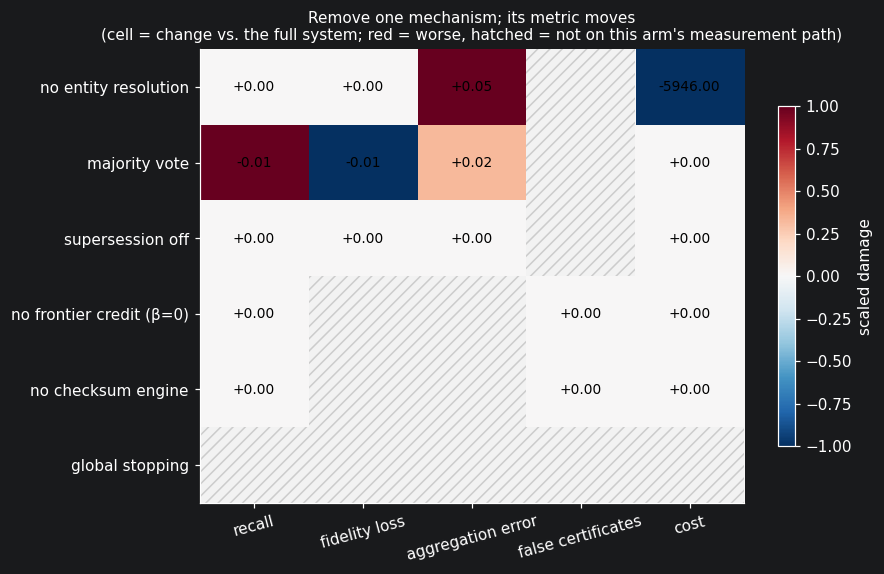

In [8]:
# --- Fig. 1: the ablation matrix -- remove a mechanism, its metric lights up --
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

arms_fig = [r for r in ablation_table["mechanism_removed"] if not r.startswith("—")]
metrics  = [("d_recall", "recall", -1),          # -1: a DROP is the damage
            ("d_loss", "fidelity loss", +1),
            ("d_agg", "aggregation error", +1),
            ("d_false_cert", "false certificates", +1),
            ("d_cost", "cost", +1)]
sub = ablation_table.set_index("mechanism_removed").loc[arms_fig]

M = np.full((len(arms_fig), len(metrics)), np.nan)
for j, (col, _, sign) in enumerate(metrics):
    v = pd.to_numeric(sub[col], errors="coerce").to_numpy(dtype=float) * sign
    m = np.nanmax(np.abs(v)) or 1.0
    M[:, j] = v / m                                 # per-column scale: worst = 1

fig, ax = plt.subplots(figsize=(8.2, 0.62 * len(arms_fig) + 1.6))
im = ax.imshow(np.nan_to_num(M, nan=0.0), cmap="RdBu_r", vmin=-1, vmax=1,
               aspect="auto")
for i in range(len(arms_fig)):                      # hatch = not on this arm's path
    for j, (col, _, _) in enumerate(metrics):
        raw = sub.iloc[i][col]
        if pd.isna(raw):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=True,
                                       facecolor="#f2f2f2", hatch="///",
                                       edgecolor="#cccccc", lw=0))
        else:
            ax.text(j, i, f"{raw:+.2f}", ha="center", va="center",
                    fontsize=9, color="black")
ax.set_xticks(range(len(metrics)),
              [name for _, name, _ in metrics], rotation=15)
ax.set_yticks(range(len(arms_fig)), arms_fig)
ax.set_title("Remove one mechanism; its metric moves\n"
             "(cell = change vs. the full system; red = worse, "
             "hatched = not on this arm's measurement path)", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.75, label="scaled damage")
fig.tight_layout()
fig.savefig(FIG_DIR / "exp7_ablation_matrix.pdf", bbox_inches="tight")
plt.show()


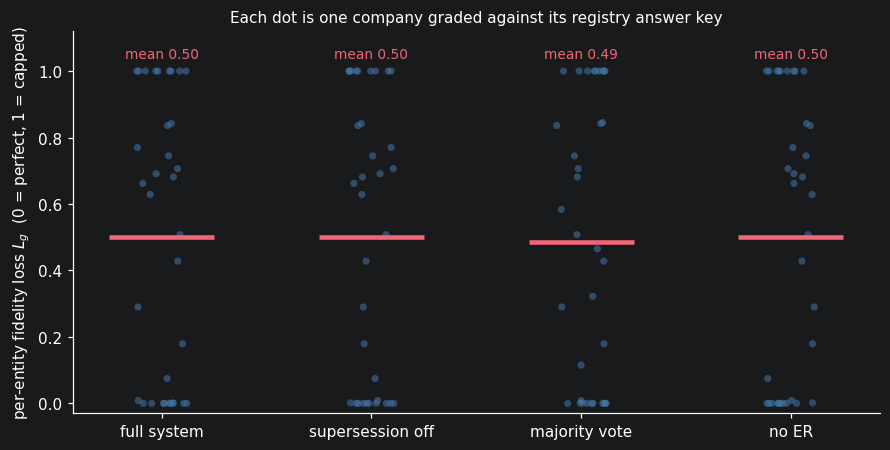

In [9]:
# --- Fig. 2: where the value-side damage lands, entity by entity --------------
order  = ["full", "supersession_off", "majority_vote", "no_er"]
labels = ["full system", "supersession off", "majority vote", "no ER"]
fig, ax = plt.subplots(figsize=(8.2, 4.2))
rng = np.random.default_rng(0)                      # jitter only; data untouched
for i, arm in enumerate(order):
    y = df_value[df_value["arm"] == arm]["loss"].to_numpy()
    ax.scatter(np.full_like(y, i, dtype=float) + rng.uniform(-.12, .12, len(y)),
               y, s=22, alpha=.55, color="#4477AA", edgecolor="none")
    ax.hlines(y.mean(), i - .25, i + .25, color="#EE6677", lw=3, zorder=3)
    ax.text(i, 1.04, f"mean {y.mean():.2f}", ha="center", fontsize=9,
            color="#EE6677")
ax.set_xticks(range(len(order)), labels)
ax.set_ylim(-0.03, 1.12)
ax.set_ylabel("per-entity fidelity loss $L_g$  (0 = perfect, 1 = capped)")
ax.set_title("Each dot is one company graded against its registry answer key",
             fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "exp7_value_loss.pdf", bbox_inches="tight")
plt.show()


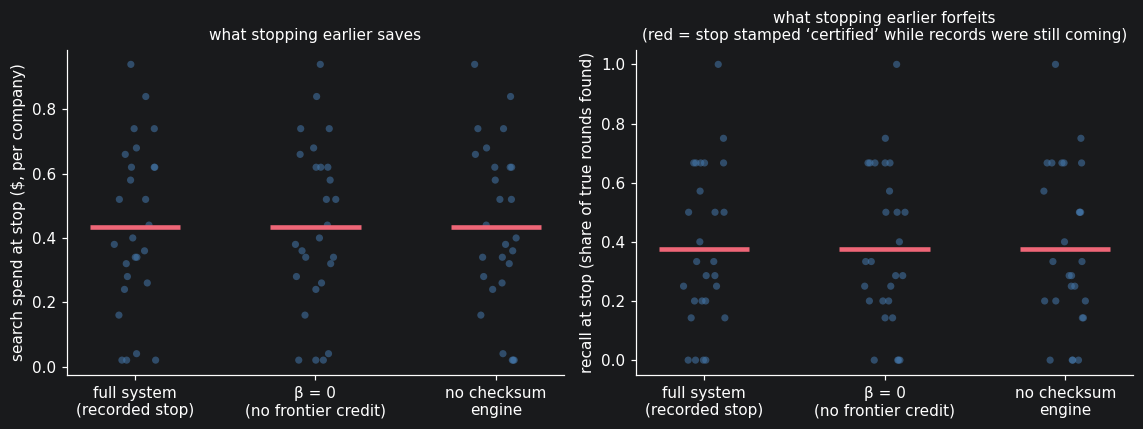

In [10]:
# --- Fig. 3: what each stopping-side removal buys, and what it forfeits -------
order  = ["full", "beta0", "checksum_off"]
labels = ["full system\n(recorded stop)", "β = 0\n(no frontier credit)",
          "no checksum\nengine"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))
rng = np.random.default_rng(1)
for i, arm in enumerate(order):
    sub = df_stop[df_stop["arm"] == arm]
    x = np.full(len(sub), i, dtype=float) + rng.uniform(-.12, .12, len(sub))
    ax1.scatter(x, sub["spent"], s=22, alpha=.55, color="#4477AA",
                edgecolor="none")
    ax1.hlines(sub["spent"].mean(), i - .25, i + .25, color="#EE6677", lw=3)
    fc = sub["false_cert"].to_numpy()
    ax2.scatter(x[~fc], sub["recall_at_stop"][~fc], s=22, alpha=.55,
                color="#4477AA", edgecolor="none")
    ax2.scatter(x[fc], sub["recall_at_stop"][fc], s=34, color="#CC3311",
                edgecolor="black", lw=.4, zorder=3,
                label="premature certificate" if (i == 1 and fc.any()) else None)
    ax2.hlines(sub["recall_at_stop"].mean(), i - .25, i + .25,
               color="#EE6677", lw=3)
ax1.set_xticks(range(3), labels); ax2.set_xticks(range(3), labels)
ax1.set_ylabel("search spend at stop ($, per company)")
ax1.set_title("what stopping earlier saves", fontsize=10)
ax2.set_ylabel("recall at stop (share of true rounds found)")
ax2.set_title("what stopping earlier forfeits\n(red = stop stamped "
              "\u2018certified\u2019 while records were still coming)", fontsize=10)
if df_stop["false_cert"].any():
    ax2.legend(loc="lower left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "exp7_stopping.pdf", bbox_inches="tight")
plt.show()


## 7 · Reading the results — the pre-registered verdicts

**The diagonal test (Fig. 1).** The design claim passes if each removal moves its own metric and
approximately nothing else: no-ER should move fidelity loss (false splits price duplicates as
spurious — the mechanism A3's attempt-#1 diagnosis showed at mean L ≈ 0.68 before the refit),
majority vote should move adopted values where echoes pile up, β = 0 should trade spend for lost
records and premature certificates, checksum-off should burn budget on strata that used to close by
constraint. A near-empty row is reported as-is: on this cohort that mechanism's removal is free,
which belongs in Limitations, not under a rug.

**Known context for two rows.** *Supersession:* the frozen pools were gathered with the registry
denied, so authority chains are scarce by construction; the `dead_excluded` meter printed in §2
says how much supersession actually did here. If it is ~0, this row's honest verdict is "inactive
on registry-denied pools" — Experiment 4 is the controlled demonstration of the mechanism itself.
*Global stopping:* Experiment 3's completed live phase found **no stopping-time gap** between the
pooled and per-group rules on any portfolio; the binding failure at web scale was per-group
*discovery* (δ_G — members the portfolio query never surfaced, including a step-1
checksum-vacuous certificate with 3 of 4 members undiscovered), not per-group stopping (ε_g). The
imported row carries that finding: the mechanism the pooled baseline actually loses is the
*promise*, not the steps.

**Limitations, stated with their bias direction.**
The checksum-off stop replay runs on a trajectory the engine still shaped (its gap-directed queries
were issued, its pruning happened), so the measured extra spend and abandonment **understate** the
true cost of removal. The β = 0 replay is exact for the stop decision but cannot add searches the
credit would have justified after the recorded horizon; misses are measured against the pool's own
future only. Value-side arms replay Π_λ over pools gathered under the full-system configuration —
the same documented interpretation the fidelity certification uses. And the false-certificate rate
for stopping arms is graded against records the pool eventually contained; records the run never
found at any step are completeness (Exp 2/3's business), invisible here by design.
